In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Data Overview

In [2]:
DF = pd.read_csv('student_habits_performance.csv')
df = pd.DataFrame(DF)
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df['parental_education_level'].describe()


count             909
unique              3
top       High School
freq              392
Name: parental_education_level, dtype: object

2. Filling missing values

In [5]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [6]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [7]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [8]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = [ col for col in cat_cols]
cat_cols.remove('student_id')
cat_cols

['gender',
 'part_time_job',
 'diet_quality',
 'parental_education_level',
 'internet_quality',
 'extracurricular_participation']

3.Visualisation of the distribution

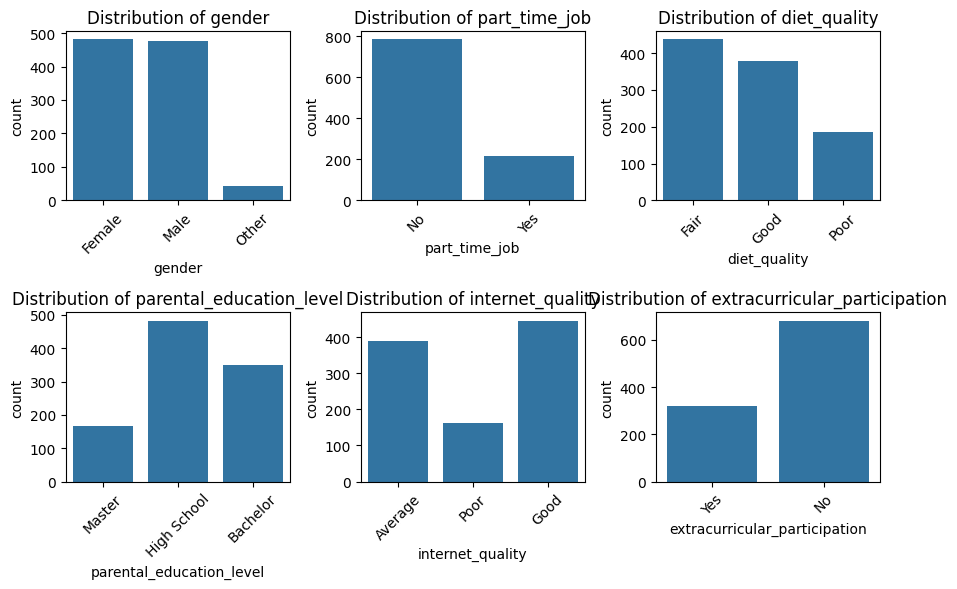

In [9]:
plt.figure(figsize=(9,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    sns.countplot(x=cat_cols[i], data=df)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {cat_cols[i]}')
plt.tight_layout()
plt.show()

In [10]:
df2 = df.drop(columns=['student_id'])
df2.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [11]:
df[cat_cols].describe()

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,1000,1000
unique,3,2,3,3,3,2
top,Female,No,Fair,High School,Good,No
freq,481,785,437,483,447,682


4.Encoding OHE + Label Encoding

In [12]:
for col in cat_cols:
    print(col)

gender
part_time_job
diet_quality
parental_education_level
internet_quality
extracurricular_participation


In [13]:
diet_quality = {'Poor': 0, 'Fair': 1, 'Good': 2}
parental_education_level = {'High School' : 0, 'Bachelor' : 1, 'Master' : 2}
internet_quality  = {'Poor' : 0, 'Average' : 1, 'Good' : 2}



In [14]:
df2['dq_2'] = df['diet_quality'].map(diet_quality)
df2['pel_2'] = df['parental_education_level'].map(parental_education_level)
df2['iq_2'] = df['internet_quality'].map(internet_quality)

In [15]:
dummies = pd.get_dummies(df[['gender', 'part_time_job', 'extracurricular_participation']], drop_first=True)

In [16]:
dummies.head()

,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,False,False,False,True
1,False,False,False,False
2,True,False,False,False
3,False,False,False,True
4,False,False,False,False


In [17]:
df3 = pd.concat([df2, dummies], axis=1)

In [18]:
df3.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,...,mental_health_rating,extracurricular_participation,exam_score,dq_2,pel_2,iq_2,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,...,8,Yes,56.2,1,2,1,False,False,False,True
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,...,8,No,100.0,2,0,1,False,False,False,False
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,...,1,No,34.3,0,0,0,True,False,False,False
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,...,1,Yes,26.8,0,2,2,False,False,False,True
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,...,1,No,66.4,1,2,2,False,False,False,False


In [19]:
df3 = df3.drop(
    columns = ['gender',   
'part_time_job',
'diet_quality',
'parental_education_level',
'internet_quality',
'extracurricular_participation']
)

In [20]:
df3.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,dq_2,pel_2,iq_2,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,1,2,1,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,2,0,1,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,0,0,0,True,False,False,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,0,2,2,False,False,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,1,2,2,False,False,False,False


5. Correlation Heatmap¶


<Axes: >

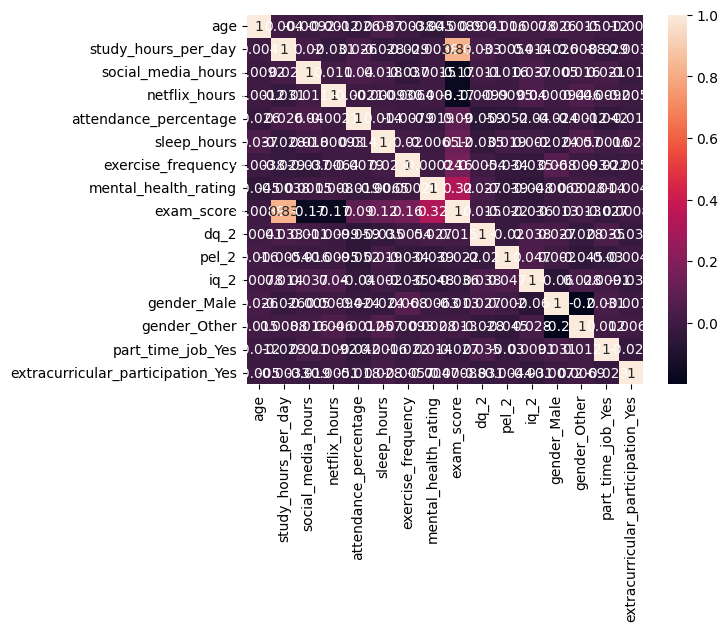

In [21]:
corr = df3.corr()
sns.heatmap(corr, annot=True)

In [22]:
df3.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,dq_2,pel_2,iq_2,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,1,2,1,False,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,2,0,1,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,0,0,0,True,False,False,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,0,2,2,False,False,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,1,2,2,False,False,False,False


In [23]:
X = df3.drop('exam_score', axis=1)
y = df3['exam_score']
X.shape , y.shape

((1000, 15), (1000,))

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(1000, 15)

6. Train Test Split

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 15), (200, 15), (800,), (200,))

In [27]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_model.score(X_test, y_test)

0.8988342264221523

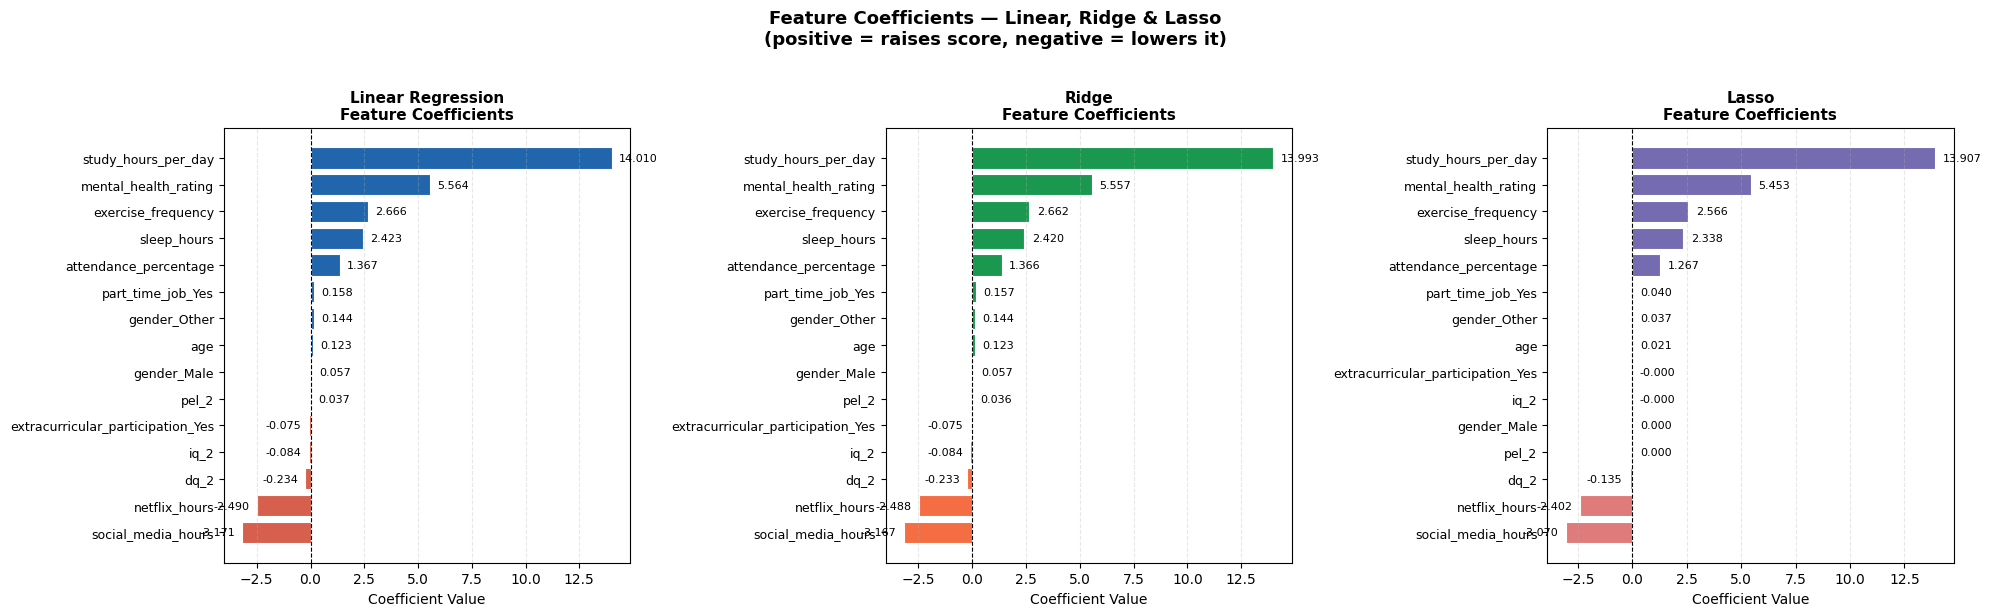

<Figure size 640x480 with 0 Axes>

In [44]:
# ── 1. Linear / Ridge / Lasso Coefficients ────────────────────────
from sklearn.linear_model import Ridge, Lasso

linear_models = {
    "Linear Regression" : models["Linear"],
    "Ridge"             : models["Ridge"],
    "Lasso"             : models["Lasso"],
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

palette = {
    "Linear Regression" : ("#2166ac", "#d6604d"),
    "Ridge"             : ("#1a9850", "#f46d43"),
    "Lasso"             : ("#756bb1", "#e07b7b"),
}

for ax, (name, model) in zip(axes, linear_models.items()):
    coefs  = pd.Series(model.coef_, index=X.columns).sort_values(ascending=True)
    pos_c, neg_c = palette[name]
    colors = [neg_c if v < 0 else pos_c for v in coefs.values]

    bars = ax.barh(coefs.index, coefs.values, color=colors,
                   edgecolor="white", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

    # ✅ Fix: dynamic offset based on actual data range (no overlap)
    x_range = coefs.values.max() - coefs.values.min()
    offset  = x_range * 0.02

    for bar, val in zip(bars, coefs.values):
        ax.text(
            val + (offset if val >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=8,
        )

    ax.set_xlabel("Coefficient Value", fontsize=10)
    ax.set_title(f"{name}\nFeature Coefficients", fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)

plt.suptitle(
    "Feature Coefficients — Linear, Ridge & Lasso\n"
    "(positive = raises score, negative = lowers it)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()


# ── 2. Random Forest Feature Importances ──────────────────────────
# rf_model       = models["Random Forest"]
# importances    = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
# colors_rf      = plt.cm.RdYlGn([v / importances.max() for v in importances.values])

# fig, ax = plt.subplots(figsize=(9, 6))
# bars = ax.barh(importances.index, importances.values,
#                color=colors_rf, edgecolor="white", linewidth=0.8)

# ✅ Fix: dynamic offset for RF too
x_range = importances.values.max()
offset  = x_range * 0.01

for bar, val in zip(bars, importances.values):
    ax.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", ha="left", fontsize=9,
    )

ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title(
    "Random Forest — Feature Importances\n"
    "(higher = more influential on exam score)",
    fontsize=12, fontweight="bold"
)
ax.grid(True, axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


# # ── 3. Side-by-side importance summary (all models) ───────────────
# summary = pd.DataFrame({
#     "Linear" : pd.Series(models["Linear"].coef_,              index=X.columns).abs(),
#     "Ridge"  : pd.Series(models["Ridge"].coef_,               index=X.columns).abs(),
#     "Lasso"  : pd.Series(models["Lasso"].coef_,               index=X.columns).abs(),
#     # "RF Imp" : pd.Series(rf_model.feature_importances_,       index=X.columns),
# })

# # Normalize each column to [0,1] for fair comparison
# summary_norm = summary.div(summary.max())
# summary_norm["avg"] = summary_norm.mean(axis=1)
# summary_norm = summary_norm.sort_values("avg", ascending=True)

# fig, ax = plt.subplots(figsize=(10, 6))
# summary_norm.drop(columns="avg").plot(
#     kind="barh", ax=ax,
#     color=["#2166ac", "#1a9850", "#756bb1", "#d6604d"],
#     edgecolor="white", linewidth=0.5, width=0.7
# )
# ax.set_xlabel("Normalized Importance (0 = least, 1 = most)", fontsize=11)
# ax.set_title(
#     "Feature Importance Comparison — All Models\n"
#     "(normalized absolute coefficients + RF importances)",
#     fontsize=12, fontweight="bold"
# )
# ax.legend(loc="lower right", fontsize=9)
# ax.grid(True, axis="x", linestyle="--", alpha=0.3)
# plt.tight_layout()
# plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Try multiple models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} → R²: {r2_score(y_test, y_pred):.3f}")

Linear → R²: 0.899
Ridge → R²: 0.899
Lasso → R²: 0.898


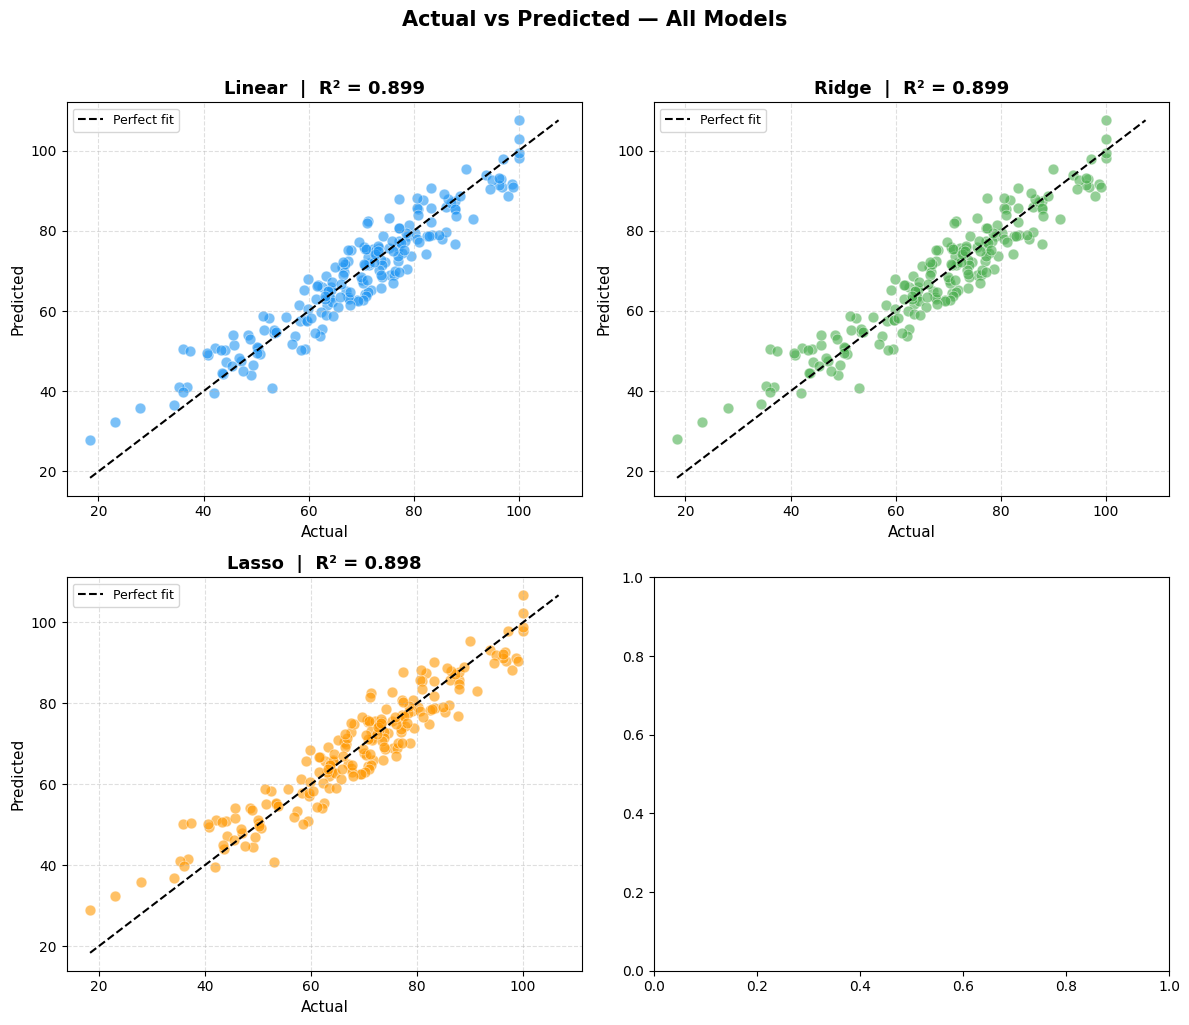

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
for ax, (name, model), color in zip(axes, models.items(), colors):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    # Scatter: actual vs predicted
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, edgecolors="white", linewidth=0.5, s=60)

    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect fit")

    ax.set_title(f"{name}  |  R² = {r2:.3f}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Actual", fontsize=11)
    ax.set_ylabel("Predicted", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Actual vs Predicted — All Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

📋 Student details you entered:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,dq_2,pel_2,iq_2,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,20,5,8,8,80,4,0,5,1,1,1,1,0,0,1



🤖 Predicted Exam Score from each model:
─────────────────────────────────────────────
  Linear                    →  43.8 / 100
  Ridge                     →  43.9 / 100
  Lasso                     →  45.2 / 100
─────────────────────────────────────────────


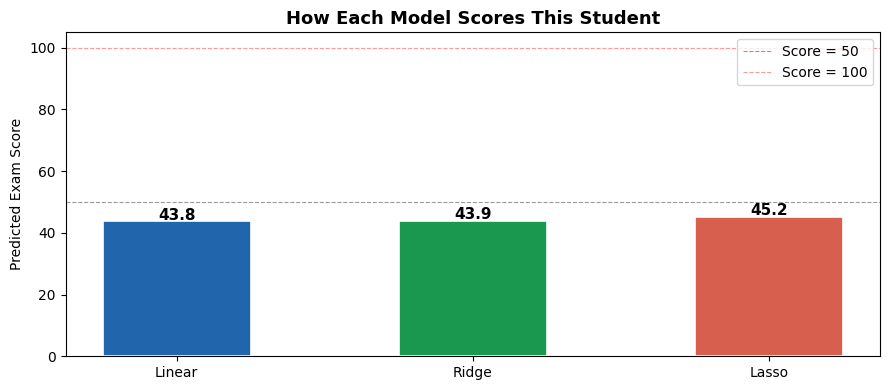


📊 Average predicted score across all models : 44.3 / 100
😟 Low score predicted — student may need support.


In [48]:
my_student = {
    "age"                              : 20,
    "study_hours_per_day"              : 5,
    "social_media_hours"               : 8,
    "netflix_hours"                    : 8,
    "attendance_percentage"            : 80,
    "sleep_hours"                      : 4,
    "exercise_frequency"               : 0,
    "mental_health_rating"             : 5,
    "dq_2"                             : 1,
    "pel_2"                            : 1,
    "iq_2"                             : 1,
    "gender_Male"                      : 1,
    "gender_Other"                     : 0,
    "part_time_job_Yes"                : 0,
    "extracurricular_participation_Yes": 1,
}

student_df     = pd.DataFrame([my_student])
student_scaled = scaler.transform(student_df)

print("📋 Student details you entered:")
display(student_df)

print("\n🤖 Predicted Exam Score from each model:")
print("─" * 45)

for name, model in models.items():
    pred         = model.predict(student_scaled)[0]
    pred_clipped = np.clip(pred, 0, 100)          # ✅ Fix 1: use clipped value in print
    print(f"  {name:<25} →  {pred_clipped:.1f} / 100")

print("─" * 45)


# ── Confidence bar for single student ─────────────────────────────
model_names = list(models.keys())
preds       = [np.clip(models[n].predict(student_scaled)[0], 0, 100) for n in model_names]  # ✅ Fix 2: clip preds for chart

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["#2166ac", "#1a9850", "#d6604d", "#756bb1", "#e07b7b"]
bars = ax.bar(model_names, preds, color=bar_colors, edgecolor="white", linewidth=1.2, width=0.5)

for bar, val in zip(bars, preds):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0, 105)                               # ✅ Fix 3: cap chart at 105 for clean look
ax.axhline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.4, label="Score = 50")
ax.axhline(100, color="red", linestyle="--", linewidth=0.8, alpha=0.4, label="Score = 100")  # ✅ Bonus: max score line
ax.set_ylabel("Predicted Exam Score")
ax.set_title("How Each Model Scores This Student", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


# ── Final verdict ──────────────────────────────────────────────────
avg_pred = np.mean(preds)                         # ✅ Already uses clipped preds now
print(f"\n📊 Average predicted score across all models : {avg_pred:.1f} / 100")

if avg_pred >= 75:
    print("🎉 Excellent! This student is predicted to score very well.")
elif avg_pred >= 60:
    print("👍 Good performance predicted — above average.")
elif avg_pred >= 45:
    print("😐 Average performance predicted.")
else:
    print("😟 Low score predicted — student may need support.")